In [35]:
import matplotlib as mpl
from matplotlib import font_manager

def set_chinese_font():
    # 按常见中文字体优先级尝试（Windows 一般有微软雅黑/黑体）
    candidates = [
        "Microsoft YaHei", "SimHei", "SimSun", "STHeiti",
        "PingFang SC", "Noto Sans CJK SC", "WenQuanYi Zen Hei"
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.sans-serif"] = [name]
            mpl.rcParams["axes.unicode_minus"] = False
            print("Using font:", name)
            return
    print("No CJK font found. Please install one (e.g., Noto Sans CJK SC).")

set_chinese_font()


Using font: Microsoft YaHei


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 可选：做线性回归（推荐 statsmodels，结果信息更全）
import statsmodels.api as sm

In [37]:
def filter_patents(
    df: pd.DataFrame,
    year_col: str = "申请年份",
    quality_col: str = "Quality_q",
    bs_col: str = "BS",
    exclude_years=None,
    quality_min: float | None = None,
    bs_min: float | None = 1e-6,   # ✅ 默认：删除 BS < 1e-6
) -> pd.DataFrame:
    """
    统一的过滤函数：
    - 排除某些申请年份（例如 1985、1986）
    - 可选：过滤掉 Quality_q < quality_min 的记录
    - 默认：过滤掉 BS < bs_min 的记录（用于去除数值噪声）
    """
    out = df.copy()

    # 年份排除
    if exclude_years is not None and len(exclude_years) > 0:
        out = out[~out[year_col].isin(exclude_years)]

    # Quality_q 最小阈值
    if quality_min is not None:
        out = out[out[quality_col].fillna(0) >= quality_min]

    # ✅ BS 最小阈值（默认启用）
    if bs_min is not None and bs_col in out.columns:
        out = out[out[bs_col].fillna(0) >= bs_min]

    return out

In [38]:
def plot_scatter_quality_vs_citations(
    df: pd.DataFrame,
    quality_col: str = "Quality_q",
    cite_col: str = "被引证次数",
    year_col: str = "申请年份",
    exclude_years=None,
    null_cite_as_zero: bool = True,
    log1p_quality: bool = False,   # ✅ 新增
    log1p_cite: bool = False,
    title: str | None = None,
    save_path: str | None = None,
):
    """
    图1（版本A）：散点图
    x = Quality_q（可选 log(1+x)）
    y = 引用次数（null -> 0，可选 log(1+y)）
    """
    d = filter_patents(
        df,
        year_col=year_col,
        quality_col=quality_col,
        exclude_years=exclude_years
    )

    # x 轴
    x_raw = pd.to_numeric(d[quality_col], errors="coerce").fillna(0)
    if log1p_quality:
        x = np.log1p(x_raw)
        x_label = f"log(1+{quality_col})"
    else:
        x = x_raw
        x_label = quality_col

    # y 轴
    y_raw = pd.to_numeric(d[cite_col], errors="coerce")
    if null_cite_as_zero:
        y_raw = y_raw.fillna(0)
    else:
        y_raw = y_raw.dropna()

    if log1p_cite:
        y = np.log1p(y_raw)
        y_label = f"log(1+{cite_col})"
    else:
        y = y_raw
        y_label = cite_col

    plt.figure()
    plt.scatter(x, y, s=8, alpha=0.4)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title or f"{x_label} vs {y_label} (scatter)")
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [68]:
def plot_scatter_with_linear_regression(
    df: pd.DataFrame,
    quality_col: str = "Quality_q",
    cite_col: str = "被引证次数",
    year_col: str = "申请年份",
    exclude_years=None,
    null_cite_as_zero: bool = True,
    log1p_quality: bool = False,   # ✅ 新增
    log1p_cite: bool = False,
    title: str | None = None,
    save_path: str | None = None,
):
    """
    图1（版本B）：散点 + 线性回归
    x / y 均支持 log(1+·) 变换
    """
    d = filter_patents(
        df,
        year_col=year_col,
        quality_col=quality_col,
        exclude_years=exclude_years
    )

    # x 轴
    x_raw = pd.to_numeric(d[quality_col], errors="coerce").fillna(0)
    if log1p_quality:
        x = np.log1p(x_raw)
        x_label = f"log(1+{quality_col})"
    else:
        x = x_raw
        x_label = quality_col

    # y 轴
    y_raw = pd.to_numeric(d[cite_col], errors="coerce")
    if null_cite_as_zero:
        y_raw = y_raw.fillna(0)
    else:
        y_raw = y_raw.dropna()

    if log1p_cite:
        y = np.log1p(y_raw)
        y_label = f"log(1+{cite_col})"
    else:
        y = y_raw
        y_label = cite_col

    # 回归：y = a + b x
    X = sm.add_constant(x)
    model = sm.OLS(y, X, missing="drop").fit()

    # 拟合线
    x_line = np.linspace(x.min(), x.max(), 200)
    X_line = sm.add_constant(x_line)
    y_line = model.predict(X_line)

    plt.figure()
    plt.scatter(x, y, s=8, alpha=0.4)
    plt.plot(x_line, y_line, linewidth=2)

    plt.xlabel(x_label)
    plt.ylabel(y_label)

    r2 = model.rsquared
    coef_name = model.params.index[1]   # 自动获取非 const 的变量名
    slope = model.params[coef_name]
    pval  = model.pvalues[coef_name]

    plt.title(title or f"{x_label} vs {y_label} (OLS fit)")
    plt.grid(True, alpha=0.3)

    plt.text(
        0.02, 0.98,
        f"R² = {r2:.4f}\nSlope = {slope:.4g}\nP-value = {pval:.4g}\nN = {int(model.nobs)}",
        transform=plt.gca().transAxes,
        va="top",
        bbox=dict(alpha=0.2)
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(model.summary())

In [75]:
def describe_and_plot_quality_distribution(
    df: pd.DataFrame,
    quality_col: str = "Quality_q",
    year_col: str = "申请年份",
    exclude_years=None,
    quality_min: float | None = None,
    bins: int = 60,
    log1p_x: bool = False,
    log_y: bool = False,
    title: str | None = None,
    save_path: str | None = None,
):
    """
    图2：Quality_q 的描述性统计 + 分布图（直方图）
    - quality_min: 可用于去掉 0 / 极小值（可选）
    - log1p_x: x 轴取 log(1+x)（适合长尾）
    - log_y: y 轴取 log（看尾部更清楚）
    """
    d = filter_patents(
        df, year_col=year_col, quality_col=quality_col,
        exclude_years=exclude_years, quality_min=quality_min
    )

    q = d[quality_col].astype(float).dropna()

    # 描述性统计（论文里可以直接贴表或写一句话引用这些数字）
    desc = q.describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])
    print("=== Descriptive statistics of Quality_q ===")
    print(desc)

    # 画图数据变换
    if log1p_x:
        # 注意：log 要求 >0，所以如果你没过滤 0，这里会出问题
        q_plot = np.log1p(q)
        x_label = f"log(1 + {quality_col})"
    else:
        q_plot = q
        x_label = quality_col

    plt.figure()
    plt.hist(q_plot, bins=bins)
    plt.xlabel(x_label)
    plt.ylabel("Frequency")
    plt.title(title or f"Distribution of {quality_col}")
    plt.grid(True, alpha=0.3)

    if log_y:
        plt.yscale("log")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return desc

In [41]:
def plot_yearly_mean_quality(
    df: pd.DataFrame,
    quality_col: str = "Quality_q",
    year_col: str = "申请年份",
    exclude_years=None,
    quality_min: float | None = 1e-5,
    title: str | None = None,
    save_path: str | None = None,
):
    """
    图3：按申请年份分组，画每年的 Quality_q 平均值
    - quality_min: 常用来去掉 0/极小值（避免均值被大量 0 拉低）
    """
    d = filter_patents(
        df, year_col=year_col, quality_col=quality_col,
        exclude_years=exclude_years, quality_min=quality_min
    )

    yearly = (
        d.groupby(year_col)[quality_col]
        .mean()
        .sort_index()
    )

    plt.figure()
    plt.plot(yearly.index, yearly.values, marker="o")
    plt.xlabel(year_col)
    plt.ylabel(f"Mean({quality_col})")
    plt.title(title or f"Yearly Mean of {quality_col} (min={quality_min})")
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return yearly


In [42]:
def plot_yearly_counts_by_thresholds(
    df: pd.DataFrame,
    quality_col: str = "Quality_q",
    year_col: str = "申请年份",
    exclude_years=None,
    thresholds=None,
    threshold_start: float = 0.5,
    threshold_end: float = 3.0,
    threshold_step: float = 0.5,
    title: str | None = None,
    save_path: str | None = None,
):
    """
    图4：按申请年份分组，统计每年 Quality_q >= threshold 的专利数量
    - thresholds: 你可以直接传一个列表，比如 [0.5, 1.0, 1.5, 2.0]
    - 如果 thresholds=None，则自动生成 threshold_start~threshold_end 的 0.5 一档线
    """
    d = filter_patents(df, year_col=year_col, quality_col=quality_col, exclude_years=exclude_years)

    if thresholds is None:
        # 注意浮点步长：用 round 规避 0.30000004 这种显示
        thresholds = [round(x, 10) for x in np.arange(threshold_start, threshold_end + 1e-12, threshold_step)]

    years = np.sort(d[year_col].dropna().unique())

    plt.figure()

    for thr in thresholds:
        tmp = d[d[quality_col].fillna(0).astype(float) >= thr]
        cnt = tmp.groupby(year_col).size().reindex(years, fill_value=0).sort_index()
        plt.plot(cnt.index, cnt.values, marker="o", label=f">= {thr}")

    plt.xlabel(year_col)
    plt.ylabel("Count")
    plt.title(title or f"Yearly counts by thresholds of {quality_col}")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)  # 线多时更紧凑

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [2]:
import pandas as pd

patent_df = pd.read_parquet("./main_enriched.parquet")
print(patent_df.shape)
print(patent_df.columns.tolist())
patent_df.head()

(5092683, 23)
['申请号', '申请年份', '专利名称', 'BS', 'FS', 'Quality_q', '申请人', '申请人类型', '申请人地址', '申请人城市', '专利类型', '公开公告年份', 'IPC主分类号', '专利权人类型', '统一社会信用代码', '引证次数', '被引证次数', '自引次数', '他引次数', '被自引次数', '被他引次数', '家族引证次数', '家族被引证次数']


,申请号,申请年份,专利名称,BS,FS,Quality_q,申请人,申请人类型,申请人地址,申请人城市,...,专利权人类型,统一社会信用代码,引证次数,被引证次数,自引次数,他引次数,被自引次数,被他引次数,家族引证次数,家族被引证次数
0,CN85106332.2,1985,一种氯化亚锡的制备方法,0.0,0.0,0.0,个旧市化工一厂,企业,云南省个旧市鸡街,红河哈尼族彝族自治州,...,None,None,NaN,18.0,NaN,NaN,NaN,18.0,NaN,26.0
1,CN85100985.9,1985,同步电动机失步保护装置,0.0,0.0,0.0,核工业部电机运行技术开发公司,企业,北京市海淀区阜成路桥西,北京市,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0
2,CN85103449.7,1985,一种冷硬铸造凸轮轴的工艺方法,0.0,0.0,0.0,清华大学,学校,北京市海淀区清华园,北京市,...,公立,12100000400000624D,NaN,2.0,NaN,NaN,NaN,2.0,1.0,4.0
3,CN85101005.9,1985,高压旋转干喷法和双管旋转干喷器,0.0,0.0,0.0,冶金工业部建筑研究总院,科研单位,北京市学院路43号,北京市,...,None,None,NaN,1.0,NaN,NaN,NaN,1.0,1.0,7.0
4,CN85101438.0,1985,框架式弹性桥机构,0.0,0.0,0.0,唐锦生,个人,北京市甘家口景王坟乙13西,北京市,...,None,None,NaN,1.0,NaN,NaN,1.0,NaN,22.0,19.0


In [22]:
exclude = [1985, 1986]


In [31]:
q = pd.to_numeric(patent_df["Quality_q"], errors="coerce")

high_q_df = patent_df[
    (q > 100) &
    (~patent_df["申请年份"].isin(exclude)) &
    (bs > 1e-6)
]

high_q_df

,申请号,申请年份,专利名称,BS,FS,Quality_q,申请人,申请人类型,申请人地址,申请人城市,...,专利权人类型,统一社会信用代码,引证次数,被引证次数,自引次数,他引次数,被自引次数,被他引次数,家族引证次数,家族被引证次数
4060,CN87103070.5,1987,数字通信机用的自动增益控制电路,0.056294,23.821536,423.165178,北京工业大学; 星光传呼(集团)有限公司,"企业,学校",北京市东郊九龙山,北京市,...,公立,12110000400687411U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4180,CN87107104.5,1987,变照度集成电路路灯光电自动控制器,0.055076,14.514518,263.538484,王国栋,个人,河南省焦作市济源钢铁厂,焦作市,...,None,None,NaN,1.0,NaN,NaN,NaN,1.0,NaN,4.0
4707,CN87103594.4,1987,一种用玉米秸秆制造板材的方法,0.059835,7.797835,130.322752,吉林省四平市水泥厂,企业,吉林省四平市铁东区北二马路110号,四平市,...,None,None,NaN,18.0,NaN,NaN,NaN,18.0,NaN,46.0
24154,CN96105013.6,1996,异步网络上不同速率数据的信元多路传输方法及系统,0.113507,18.980714,167.220470,财团法人工业技术研究院,科研单位,台湾省新竹县,台湾省,...,None,None,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN
49670,CN00134030.1,2000,提高短消息调度中心消息处理能力的方法,2.172194,229.696678,105.744068,华为技术有限公司,企业,518057广东省深圳市科技园科发路华为用服大厦,深圳市,...,有限责任公司(法人独资),914403001922038216,NaN,3.0,NaN,NaN,2.0,1.0,NaN,12.0
54537,CN01135671.5,2001,利用缓存技术提高IP报文转发速度的方法,2.491548,442.486477,177.595005,华为技术有限公司,企业,518057广东省深圳市南山区科技园科发路1号,深圳市,...,有限责任公司(法人独资),914403001922038216,NaN,1.0,NaN,NaN,NaN,1.0,NaN,11.0
56907,CN01139038.7,2001,易扩展型网络入侵检测与安全审计系统,0.056488,13.378189,236.834188,上海复旦光华信息科技股份有限公司,企业,200437上海市邯郸路191号,上海市,...,None,None,NaN,3.0,NaN,NaN,NaN,3.0,NaN,14.0
58128,CN01123934.4,2001,数据报文传输序列号合法性的检查方法,1.766742,284.667248,161.125566,华为技术有限公司,企业,518057广东省深圳市科技园科发路华为用服大厦,深圳市,...,有限责任公司(法人独资),914403001922038216,NaN,1.0,NaN,NaN,1.0,NaN,NaN,11.0
547160,CN201010274350.9,2010,功耗控制方法、管理节点及数据处理中心,10.246009,1430.448090,139.610269,联想(北京)有限公司,企业,100085 北京市海淀区上地信息产业基地上地西路6号,北京市,...,有限责任公司(台港澳法人独资),91110108700000458B,4.0,2.0,1.0,3.0,NaN,2.0,8.0,10.0
548357,CN201010116283.8,2010,M2M业务平台及其与下一代业务网络融合的方法和系统,17.582148,2218.192108,126.161608,中兴通讯股份有限公司,企业,518057 广东省深圳市南山区高新技术产业园科技南路中兴通讯大厦法务部,深圳市,...,上市股份有限公司,9144030027939873X7,4.0,NaN,1.0,3.0,NaN,NaN,4.0,12.0


In [28]:
bs = pd.to_numeric(patent_df["BS"], errors="coerce")
bs.describe(percentiles=[0.0001, 0.0005, 0.001, 0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])

count    5.092683e+06
mean     7.361638e+02
std      6.392495e+02
min      0.000000e+00
0.01%    0.000000e+00
0.05%    0.000000e+00
0.1%     1.034023e+00
1%       1.347129e+01
5%       6.349968e+01
10%      1.188858e+02
50%      5.642073e+02
90%      1.577556e+03
95%      1.991950e+03
99%      2.943210e+03
max      8.028268e+03
Name: BS, dtype: float64

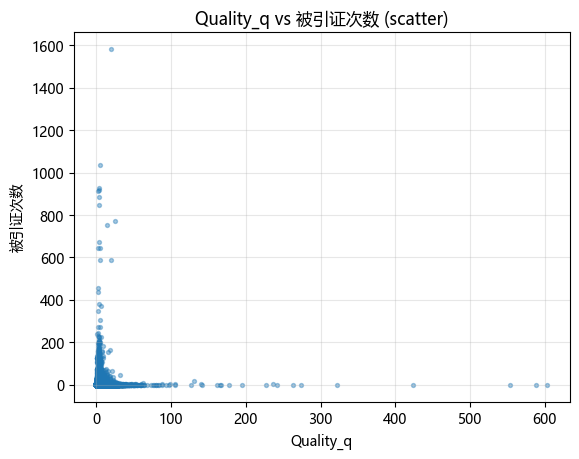

In [45]:
# 图1A：散点（被引证次数）
plot_scatter_quality_vs_citations(patent_df, quality_col="Quality_q", cite_col="被引证次数",
                                  year_col="申请年份", exclude_years=exclude,
                                  null_cite_as_zero=True, log1p_cite=False, log1p_quality=False)

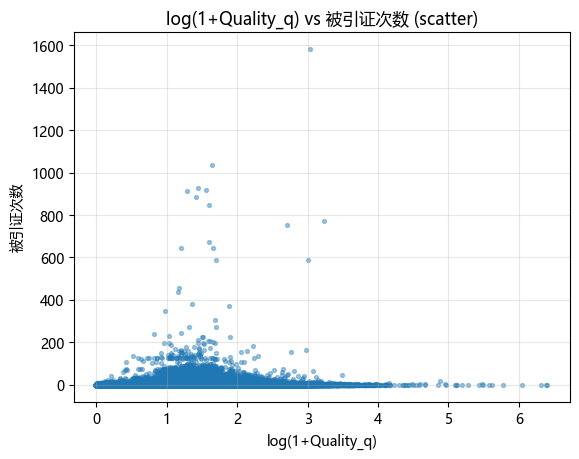

In [46]:
# 图1A：散点（被引证次数）
plot_scatter_quality_vs_citations(patent_df, quality_col="Quality_q", cite_col="被引证次数",
                                  year_col="申请年份", exclude_years=exclude,
                                  null_cite_as_zero=True, log1p_cite=False, log1p_quality=True)

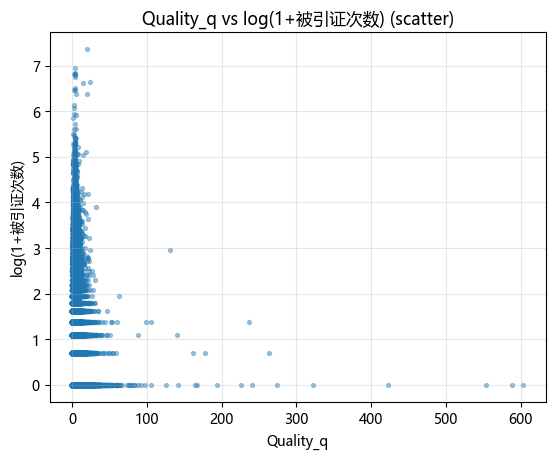

In [47]:
# 图1A：散点（被引证次数）
plot_scatter_quality_vs_citations(patent_df, quality_col="Quality_q", cite_col="被引证次数",
                                  year_col="申请年份", exclude_years=exclude,
                                  null_cite_as_zero=True, log1p_cite=True, log1p_quality=False)

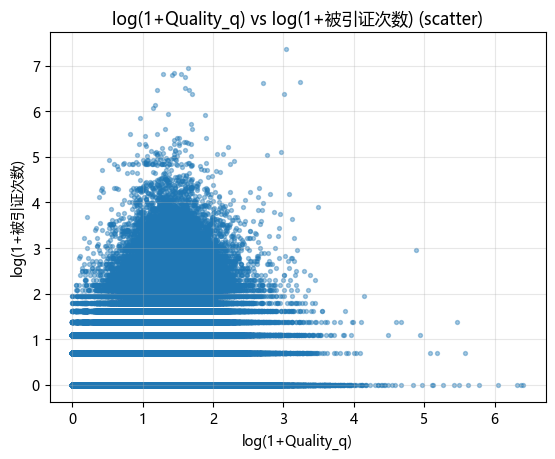

In [66]:
# 图1A：散点（被引证次数）
plot_scatter_quality_vs_citations(patent_df, quality_col="Quality_q", cite_col="被引证次数",
                                  year_col="申请年份", exclude_years=exclude,
                                  null_cite_as_zero=True, log1p_cite=True, log1p_quality=True)

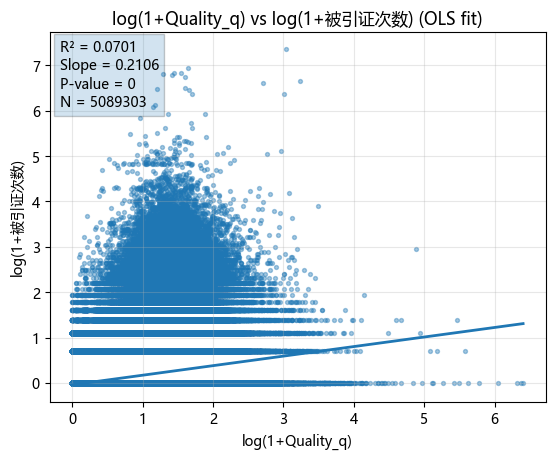

                            OLS Regression Results                            
Dep. Variable:                  被引证次数   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                 3.839e+05
Date:                Wed, 07 Jan 2026   Prob (F-statistic):               0.00
Time:                        22:56:25   Log-Likelihood:            -2.2747e+06
No. Observations:             5089303   AIC:                         4.549e+06
Df Residuals:                 5089301   BIC:                         4.549e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0417      0.000   -128.486      0.0

In [69]:
plot_scatter_with_linear_regression(
    patent_df,
    quality_col="Quality_q",
    cite_col="被引证次数",
    year_col="申请年份",
    exclude_years=exclude,
    log1p_quality=True,
    log1p_cite=True
)

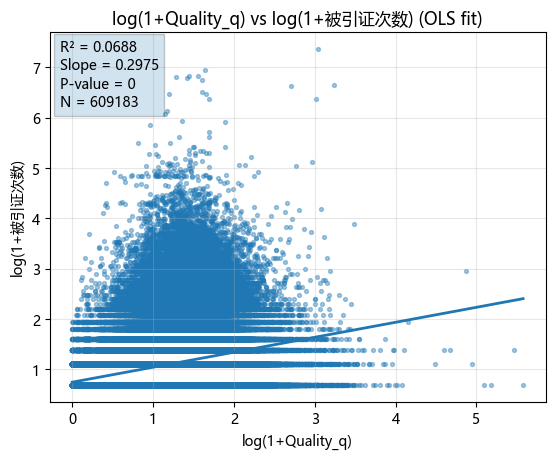

                            OLS Regression Results                            
Dep. Variable:                  被引证次数   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                 4.500e+04
Date:                Wed, 07 Jan 2026   Prob (F-statistic):               0.00
Time:                        22:31:27   Log-Likelihood:            -4.1111e+05
No. Observations:              609183   AIC:                         8.222e+05
Df Residuals:                  609181   BIC:                         8.223e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7441      0.002    428.808      0.0

In [52]:
df_pos = patent_df[
    pd.to_numeric(patent_df["被引证次数"], errors="coerce") > 0
]
plot_scatter_with_linear_regression(
    df_pos,
    quality_col="Quality_q",
    cite_col="被引证次数",
    year_col="申请年份",
    exclude_years=exclude,
    log1p_quality=True,
    log1p_cite=True
)

=== Descriptive statistics of Quality_q ===
count    5.082978e+06
mean     1.568028e+00
std      1.543835e+00
min      1.032900e-04
1%       3.361438e-03
5%       6.463051e-02
10%      1.676487e-01
50%      1.294204e+00
90%      3.297576e+00
95%      4.032805e+00
99%      6.009299e+00
max      6.034266e+02
Name: Quality_q, dtype: float64


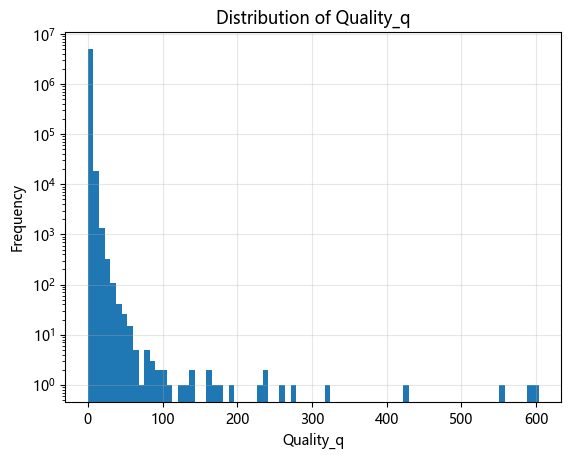

count    5.082978e+06
mean     1.568028e+00
std      1.543835e+00
min      1.032900e-04
1%       3.361438e-03
5%       6.463051e-02
10%      1.676487e-01
50%      1.294204e+00
90%      3.297576e+00
95%      4.032805e+00
99%      6.009299e+00
max      6.034266e+02
Name: Quality_q, dtype: float64

In [73]:
# 图2：分布+描述统计（建议 quality_min=1e-5 去掉 0）
describe_and_plot_quality_distribution(patent_df, quality_col="Quality_q",
                                      year_col="申请年份", exclude_years=exclude,
                                      quality_min=1e-4, bins=80, log1p_x=False, log_y=True)

=== Descriptive statistics of Quality_q ===
count    5.082978e+06
mean     1.568028e+00
std      1.543835e+00
min      1.032900e-04
1%       3.361438e-03
5%       6.463051e-02
10%      1.676487e-01
50%      1.294204e+00
90%      3.297576e+00
95%      4.032805e+00
99%      6.009299e+00
max      6.034266e+02
Name: Quality_q, dtype: float64


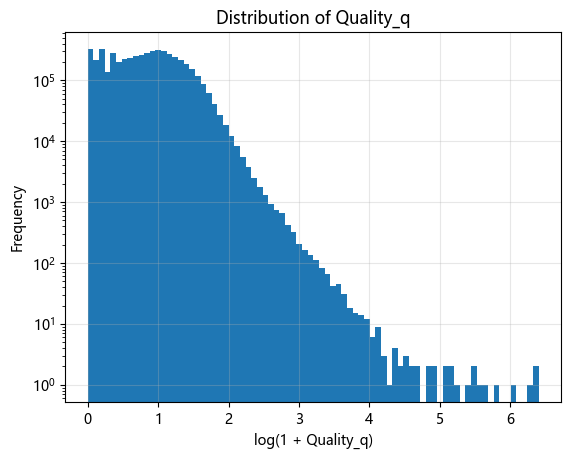

count    5.082978e+06
mean     1.568028e+00
std      1.543835e+00
min      1.032900e-04
1%       3.361438e-03
5%       6.463051e-02
10%      1.676487e-01
50%      1.294204e+00
90%      3.297576e+00
95%      4.032805e+00
99%      6.009299e+00
max      6.034266e+02
Name: Quality_q, dtype: float64

In [76]:
# 图2：分布+描述统计（建议 quality_min=1e-5 去掉 0）
describe_and_plot_quality_distribution(patent_df, quality_col="Quality_q",
                                      year_col="申请年份", exclude_years=exclude,
                                      quality_min=1e-4, bins=80, log1p_x=True, log_y=True)

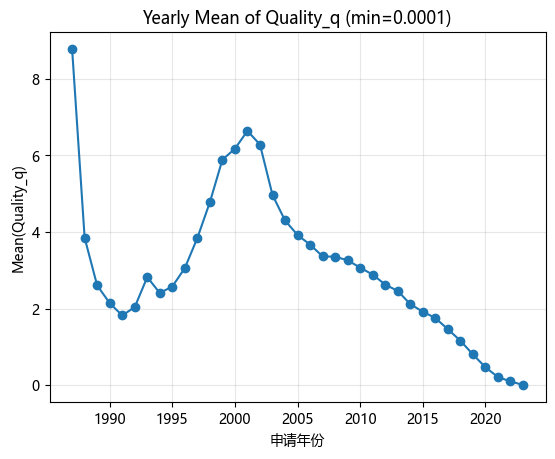

申请年份
1987    8.784351
1988    3.850315
1989    2.604937
1990    2.144137
1991    1.820643
1992    2.038403
1993    2.822161
1994    2.406800
1995    2.576418
1996    3.058791
1997    3.845024
1998    4.780005
1999    5.890615
2000    6.176754
2001    6.642987
2002    6.284886
2003    4.967850
2004    4.301751
2005    3.923203
2006    3.670760
2007    3.364827
2008    3.354695
2009    3.261765
2010    3.069050
2011    2.887181
2012    2.627248
2013    2.460283
2014    2.115644
2015    1.918237
2016    1.754220
2017    1.460199
2018    1.161207
2019    0.801811
2020    0.467662
2021    0.210422
2022    0.097620
2023    0.005557
Name: Quality_q, dtype: float64

In [80]:
# 图3：按年均值
plot_yearly_mean_quality(patent_df, quality_col="Quality_q",
                         year_col="申请年份", exclude_years=[1985, 1986], quality_min=1e-4)

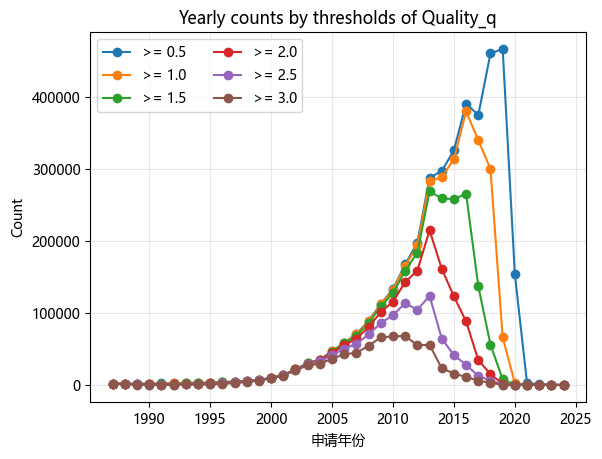

In [ ]:
# 图4：按年计数，多阈值曲线（0.5 一档）
plot_yearly_counts_by_thresholds(patent_df, quality_col="Quality_q",
                                year_col="申请年份", exclude_years=exclude,
                                threshold_start=0.5, threshold_end=3.0, threshold_step=0.5)

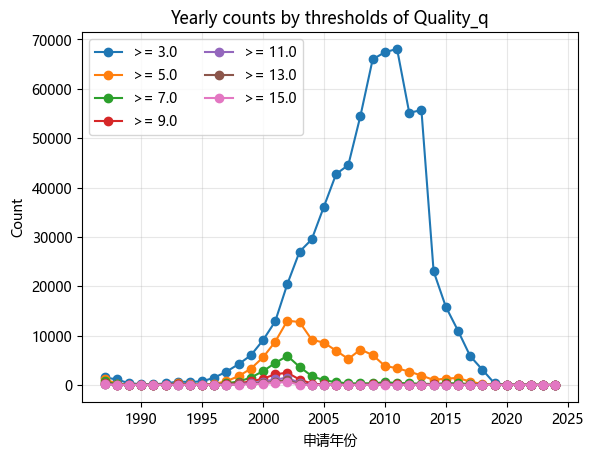

In [82]:

# 图4：按年计数，多阈值曲线（0.5 一档）
plot_yearly_counts_by_thresholds(patent_df, quality_col="Quality_q",
                                year_col="申请年份", exclude_years=exclude,
                                threshold_start=3, threshold_end=15, threshold_step=2)

In [98]:
# 描述性统计
import pandas as pd
import numpy as np

# 基础清洗
df = filter_patents(
    patent_df,
    exclude_years=[1985, 1986],
)

# 确保是数值
df["Quality_q"] = pd.to_numeric(df["Quality_q"], errors="coerce")
df["被引证次数"] = pd.to_numeric(df["被引证次数"], errors="coerce").fillna(0)

# 三个序列
q_all = df["Quality_q"].dropna()
q_ge5 = df.loc[df["Quality_q"] >= 5, "Quality_q"]
cites_all = df["被引证次数"]

In [99]:
def describe_series(s: pd.Series):
    return {
        "N": s.count(),
        "Mean": s.mean(),
        "Std. Dev.": s.std(),
        "Min": s.min(),
        "P25": s.quantile(0.25),
        "Median": s.quantile(0.50),
        "P75": s.quantile(0.75),
        "P90": s.quantile(0.90),
        "P95": s.quantile(0.95),
        "P99": s.quantile(0.99),
        "Max": s.max(),
    }


In [100]:
table = pd.DataFrame({
    "Quality_q (All)": describe_series(q_all),
    "Quality_q ≥ 5": describe_series(q_ge5),
    "Citations": describe_series(cites_all),
})


In [101]:
table_fmt = table.copy()

for col in table_fmt.columns:
    table_fmt[col] = table_fmt[col].apply(
        lambda x: f"{x:,.3f}" if isinstance(x, float) else f"{int(x):,}"
    )


In [102]:
table_fmt 

,Quality_q (All),Quality_q ≥ 5,Citations
N,"5,089,303.000","107,975.000","5,089,303.000"
Mean,1.566,6.787,0.305
Std. Dev.,1.544,4.978,2.191
Min,0.000,5.000,0.000
P25,0.488,5.360,0.000
Median,1.292,5.923,0.000
P75,2.238,7.026,0.000
P90,3.296,8.907,1.000
P95,4.031,10.933,2.000
P99,6.008,17.927,5.000


In [103]:
latex_str = table_fmt.to_latex(
    caption="Descriptive Statistics of Patent Innovation and Citations",
    label="tab:desc_stats",
    column_format="lccc",
    escape=False
)

print(latex_str)

\begin{table}
\caption{Descriptive Statistics of Patent Innovation and Citations}
\label{tab:desc_stats}
\begin{tabular}{lccc}
\toprule
 & Quality_q (All) & Quality_q ≥ 5 & Citations \\
\midrule
N & 5,089,303.000 & 107,975.000 & 5,089,303.000 \\
Mean & 1.566 & 6.787 & 0.305 \\
Std. Dev. & 1.544 & 4.978 & 2.191 \\
Min & 0.000 & 5.000 & 0.000 \\
P25 & 0.488 & 5.360 & 0.000 \\
Median & 1.292 & 5.923 & 0.000 \\
P75 & 2.238 & 7.026 & 0.000 \\
P90 & 3.296 & 8.907 & 1.000 \\
P95 & 4.031 & 10.933 & 2.000 \\
P99 & 6.008 & 17.927 & 5.000 \\
Max & 603.427 & 603.427 & 1,583.000 \\
\bottomrule
\end{tabular}
\end{table}



In [117]:
import pandas as pd
import numpy as np

# -----------------------------
# 0) 参数：列名按你的数据改一下
# -----------------------------
PATENT_UCC_COL = "统一社会信用代码"   # patent_df 里的统一社会信用代码列
QUALITY_COL = "Quality_q"            # patent_df 里的创新指标列
YEAR_COL = "申请年份"                # 如果你后面要排除年份可用；本次不必
SPECIAL_UCC_COL = "统一社会信用代码" # 专精特新名单 df 里的统一社会信用代码列

QUALITY_THRESHOLD = 1.0              # 你要求的 >=5
USE_LOG1P = True                     # True: log(1+N)；False: log(N)


In [ ]:
# 1) 读入“专精特新公司”名单（你已经读好了也可以跳过）
# -----------------------------
special_df = pd.read_stata(r"./科创企业名单2024.dta")

In [119]:
# 统一社会信用代码统一成字符串，避免前导0/科学计数法/数值被截断
special_ucc = (
    special_df[SPECIAL_UCC_COL]
    .astype(str)
    .str.strip()
)
special_ucc_set = set(special_ucc.dropna().unique())

In [120]:
# -----------------------------
# 2) 从 patent_df 出发：先丢掉没有统一社会信用代码的专利
#    若存在多个，用 ; 分隔，则取第一个
# -----------------------------
p = patent_df.copy()

# 统一社会信用代码 -> str
p[PATENT_UCC_COL] = (
    p[PATENT_UCC_COL]
    .astype(str)
    .str.strip()
    .str.split(";", n=1)   # 只按第一个 ; 分割
    .str[0]                # 取第一个信用代码
    .str.strip()
)

# 丢掉空 / "nan" / "None"
p = p[p[PATENT_UCC_COL].notna()]
p = p[~p[PATENT_UCC_COL].isin(["", "nan", "None", "NaN"])]

# Quality_q 转成数值
p[QUALITY_COL] = pd.to_numeric(p[QUALITY_COL], errors="coerce")


In [121]:
# 看看有多少专利原本是多主体
multi_ucc_share = (
    patent_df[PATENT_UCC_COL]
    .astype(str)
    .str.contains(";")
    .mean()
)

print(f"Share of patents with multiple UCCs: {multi_ucc_share:.2%}")


Share of patents with multiple UCCs: 8.26%


In [122]:
# -----------------------------
# 3) 公司层面聚合：总专利数 + 高创新专利数(>=5)
# -----------------------------
company_agg = (
    p.groupby(PATENT_UCC_COL)
     .agg(
         total_patents=(QUALITY_COL, "size"),
         high_q_count=(QUALITY_COL, lambda s: (s.fillna(-np.inf) >= QUALITY_THRESHOLD).sum())
     )
     .reset_index()
)

# log 总专利数（推荐 log1p 避免 log(0)，虽然这里 total_patents>=1）
if USE_LOG1P:
    company_agg["log_total_patents"] = np.log1p(company_agg["total_patents"])
    log_col_name = "log(1+Total patents)"
else:
    company_agg["log_total_patents"] = np.log(company_agg["total_patents"])
    log_col_name = "log(Total patents)"


In [123]:
# -----------------------------
# 4) 标注是否“专精特新公司”
# -----------------------------
company_agg["is_special"] = company_agg[PATENT_UCC_COL].isin(special_ucc_set)

special_company = company_agg[company_agg["is_special"]].copy()
other_company   = company_agg[~company_agg["is_special"]].copy()

In [124]:
# -----------------------------
# 5) 描述性统计函数（公司层面）
# -----------------------------
def describe_series(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce").dropna()
    return {
        "N (companies)": int(s.count()),
        "Mean": s.mean(),
        "Std. Dev.": s.std(),
        "Min": s.min(),
        "P25": s.quantile(0.25),
        "Median": s.quantile(0.50),
        "P75": s.quantile(0.75),
        "P90": s.quantile(0.90),
        "P95": s.quantile(0.95),
        "P99": s.quantile(0.99),
        "Max": s.max(),
    }

def build_desc_table(df_company: pd.DataFrame, group_name: str):
    cols = {
        f"{group_name}: #Patents with Quality_q ≥ {QUALITY_THRESHOLD:g}": "high_q_count",
        f"{group_name}: Total patents": "total_patents",
        f"{group_name}: {log_col_name}": "log_total_patents",
    }
    out = pd.DataFrame({k: describe_series(df_company[v]) for k, v in cols.items()})
    return out

tab_special = build_desc_table(special_company, "Special firms")
tab_other   = build_desc_table(other_company,   "Other firms")

# 你可以选择：先只输出“专精特新公司”这一类（按你的要求）
tab = tab_special




In [125]:
tab

,Special firms: #Patents with Quality_q ≥ 1,Special firms: Total patents,Special firms: log(1+Total patents)
N (companies),258781.000000,258781.000000,258781.000000
Mean,4.779574,8.849116,1.410378
Std. Dev.,133.559442,174.608616,0.867416
Min,0.000000,1.000000,0.693147
P25,0.000000,1.000000,0.693147
Median,1.000000,2.000000,1.098612
P75,2.000000,5.000000,1.791759
P90,6.000000,12.000000,2.564949
P95,12.000000,22.000000,3.135494
P99,47.000000,82.000000,4.418841


In [126]:
# -----------------------------
# 6) 数值格式化 + 导出 LaTeX（booktabs）
# -----------------------------
tab_fmt = tab.copy()
for c in tab_fmt.columns:
    tab_fmt[c] = tab_fmt[c].apply(lambda x: f"{x:,.3f}" if isinstance(x, float) else f"{x:,}")

latex_str = tab_fmt.to_latex(
    caption=f"Descriptive Statistics at Firm Level (Special firms only)",
    label="tab:firm_desc_special",
    column_format="lccc",  # 1列统计量 + 3列变量
    escape=False,
    bold_rows=False
)

# 强制加 booktabs 的顶线/底线（pandas 默认已经是 booktabs 风格，但这里更保险）
# 如果你发现没有 top/bottom rule，请确保导言区有 \usepackage{booktabs}
print(latex_str)



\begin{table}
\caption{Descriptive Statistics at Firm Level (Special firms only)}
\label{tab:firm_desc_special}
\begin{tabular}{lccc}
\toprule
 & Special firms: #Patents with Quality_q ≥ 1 & Special firms: Total patents & Special firms: log(1+Total patents) \\
\midrule
N (companies) & 258,781.000 & 258,781.000 & 258,781.000 \\
Mean & 4.780 & 8.849 & 1.410 \\
Std. Dev. & 133.559 & 174.609 & 0.867 \\
Min & 0.000 & 1.000 & 0.693 \\
P25 & 0.000 & 1.000 & 0.693 \\
Median & 1.000 & 2.000 & 1.099 \\
P75 & 2.000 & 5.000 & 1.792 \\
P90 & 6.000 & 12.000 & 2.565 \\
P95 & 12.000 & 22.000 & 3.135 \\
P99 & 47.000 & 82.000 & 4.419 \\
Max & 51,362.000 & 61,897.000 & 11.033 \\
\bottomrule
\end{tabular}
\end{table}



In [127]:
# -----------------------------
# 7) （可选）把“专精特新 vs 其他”拼成一张更像论文的表
#     ——两组并排对比（更推荐放论文）
# -----------------------------
tab_both = pd.concat([tab_special, tab_other], axis=1)
tab_both_fmt = tab_both.copy()
for c in tab_both_fmt.columns:
    tab_both_fmt[c] = tab_both_fmt[c].apply(lambda x: f"{x:,.3f}" if isinstance(x, float) else f"{x:,}")

latex_both = tab_both_fmt.to_latex(
    caption="Descriptive Statistics at Firm Level: Special vs Other Firms",
    label="tab:firm_desc_both",
    column_format="l" + "c"*tab_both_fmt.shape[1],
    escape=False
)
print(latex_both)

\begin{table}
\caption{Descriptive Statistics at Firm Level: Special vs Other Firms}
\label{tab:firm_desc_both}
\begin{tabular}{lcccccc}
\toprule
 & Special firms: #Patents with Quality_q ≥ 1 & Special firms: Total patents & Special firms: log(1+Total patents) & Other firms: #Patents with Quality_q ≥ 1 & Other firms: Total patents & Other firms: log(1+Total patents) \\
\midrule
N (companies) & 258,781.000 & 258,781.000 & 258,781.000 & 174,877.000 & 174,877.000 & 174,877.000 \\
Mean & 4.780 & 8.849 & 1.410 & 6.707 & 11.601 & 1.109 \\
Std. Dev. & 133.559 & 174.609 & 0.867 & 168.437 & 255.092 & 0.761 \\
Min & 0.000 & 1.000 & 0.693 & 0.000 & 1.000 & 0.693 \\
P25 & 0.000 & 1.000 & 0.693 & 0.000 & 1.000 & 0.693 \\
Median & 1.000 & 2.000 & 1.099 & 1.000 & 1.000 & 0.693 \\
P75 & 2.000 & 5.000 & 1.792 & 1.000 & 2.000 & 1.099 \\
P90 & 6.000 & 12.000 & 2.565 & 3.000 & 6.000 & 1.946 \\
P95 & 12.000 & 22.000 & 3.135 & 7.000 & 11.000 & 2.485 \\
P99 & 47.000 & 82.000 & 4.419 & 37.000 & 70.000 & 4.263

In [128]:
tab_both

,Special firms: #Patents with Quality_q ≥ 1,Special firms: Total patents,Special firms: log(1+Total patents),Other firms: #Patents with Quality_q ≥ 1,Other firms: Total patents,Other firms: log(1+Total patents)
N (companies),258781.000000,258781.000000,258781.000000,174877.000000,174877.000000,174877.000000
Mean,4.779574,8.849116,1.410378,6.706599,11.601068,1.108872
Std. Dev.,133.559442,174.608616,0.867416,168.436896,255.091904,0.760577
Min,0.000000,1.000000,0.693147,0.000000,1.000000,0.693147
P25,0.000000,1.000000,0.693147,0.000000,1.000000,0.693147
Median,1.000000,2.000000,1.098612,1.000000,1.000000,0.693147
P75,2.000000,5.000000,1.791759,1.000000,2.000000,1.098612
P90,6.000000,12.000000,2.564949,3.000000,6.000000,1.945910
P95,12.000000,22.000000,3.135494,7.000000,11.000000,2.484907
P99,47.000000,82.000000,4.418841,37.000000,70.000000,4.262680


In [129]:
import numpy as np
import pandas as pd

# Welch t-test（建议）
try:
    from scipy import stats
except ImportError:
    raise ImportError("需要安装 scipy：pip install scipy")

def _star(p):
    """显著性星号"""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.1:
        return "*"
    return ""

def _welch_ttest(a, b):
    """Welch t-test：返回 (t, p)"""
    a = pd.to_numeric(pd.Series(a), errors="coerce").dropna()
    b = pd.to_numeric(pd.Series(b), errors="coerce").dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan
    t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    return float(t), float(p)

def _fmt(x, digits=3, int_like=False):
    if pd.isna(x):
        return ""
    if int_like:
        return f"{int(round(x)):,}"
    return f"{x:,.{digits}f}"

def build_group_comparison_table(
    firm_df: pd.DataFrame,
    group_col: str = "is_special",
    var_specs=None,
    percentiles=(0.50, 0.90),
    digits=3,
    use_mannwhitney=False,
):
    """
    输出论文常见的：Special / Other / Diff / t-stat(p-value) 的对比表

    firm_df: 公司层面数据（每行一个统一社会信用代码）
    group_col: True=Special, False=Other
    var_specs: [(显示名, 列名, 是否整数变量), ...]
    percentiles: 你希望展示的分位数（默认 Median & P90）
    use_mannwhitney: 若 True，会额外计算 Mann-Whitney U 的 p-value（可选）
    """
    if var_specs is None:
        var_specs = [
            ("#Patents with Quality_q ≥ 1", "high_q_count", True),
            ("Total patents", "total_patents", True),
            ("log(1+Total patents)", "log_total_patents", False),
        ]

    df = firm_df.copy()
    # 分组
    g1 = df[df[group_col] == True]   # Special
    g0 = df[df[group_col] == False]  # Other

    rows = []

    # 第一行：公司数量 N（不做t检验）
    rows.append({
        "Statistic": "N (firms)",
        "Special": _fmt(len(g1), int_like=True),
        "Other": _fmt(len(g0), int_like=True),
        "Diff": "",
        "t-stat": "",
        "p-value": ""
    })

    # 对每个变量做一组：Mean/Std/Percentiles + Diff + ttest
    for disp_name, col, is_int in var_specs:
        a = pd.to_numeric(g1[col], errors="coerce").dropna()
        b = pd.to_numeric(g0[col], errors="coerce").dropna()

        # 均值、标准差、分位数
        mean_a, mean_b = a.mean(), b.mean()
        std_a, std_b = a.std(), b.std()
        qs_a = {q: a.quantile(q) for q in percentiles}
        qs_b = {q: b.quantile(q) for q in percentiles}

        # t-test（Welch）
        t, p = _welch_ttest(a, b)
        diff = mean_a - mean_b
        star = _star(p)

        # 变量标题行（让表更像论文）
        rows.append({
            "Statistic": f"{disp_name}",
            "Special": "",
            "Other": "",
            "Diff": "",
            "t-stat": "",
            "p-value": ""
        })

        # Mean 行（附显著性）
        rows.append({
            "Statistic": "  Mean",
            "Special": _fmt(mean_a, digits=digits, int_like=False),
            "Other": _fmt(mean_b, digits=digits, int_like=False),
            "Diff": f"{_fmt(diff, digits=digits)}{star}",
            "t-stat": _fmt(t, digits=3),
            "p-value": _fmt(p, digits=3),
        })

        # Std 行
        rows.append({
            "Statistic": "  Std. Dev.",
            "Special": _fmt(std_a, digits=digits),
            "Other": _fmt(std_b, digits=digits),
            "Diff": "",
            "t-stat": "",
            "p-value": ""
        })

        # 分位数行：Median, P90, ...
        for q in percentiles:
            label = "  Median" if q == 0.50 else f"  P{int(q*100)}"
            rows.append({
                "Statistic": label,
                "Special": _fmt(qs_a[q], digits=digits),
                "Other": _fmt(qs_b[q], digits=digits),
                "Diff": _fmt(qs_a[q] - qs_b[q], digits=digits),
                "t-stat": "",
                "p-value": ""
            })

        # （可选）非参数检验：Mann-Whitney U（更适合偏态）
        if use_mannwhitney:
            try:
                u_stat, p_u = stats.mannwhitneyu(a, b, alternative="two-sided")
                rows.append({
                    "Statistic": "  Mann-Whitney p-value",
                    "Special": "",
                    "Other": "",
                    "Diff": "",
                    "t-stat": "",
                    "p-value": _fmt(p_u, digits=3)
                })
            except Exception:
                pass

    out = pd.DataFrame(rows, columns=["Statistic", "Special", "Other", "Diff", "t-stat", "p-value"])
    return out


def export_latex_booktabs(df_table: pd.DataFrame, caption: str, label: str, path: str | None = None):
    """
    导出 booktabs 风格 LaTeX 表格。
    论文导言区记得：\\usepackage{booktabs}
    """
    latex = df_table.to_latex(
        index=False,
        escape=False,
        caption=caption,
        label=label,
        column_format="lccccc"
    )
    if path:
        with open(path, "w", encoding="utf-8") as f:
            f.write(latex)
    return latex


In [130]:
# company_agg 应该至少包含：
# ['统一社会信用代码', 'total_patents', 'high_q_count', 'log_total_patents', 'is_special']

# 生成对比表
comp_tab = build_group_comparison_table(
    firm_df=company_agg,
    group_col="is_special",
    var_specs=[
        ("#Patents with Quality_q ≥ 1", "high_q_count", True),
        ("Total patents", "total_patents", True),
        ("log(1+Total patents)", "log_total_patents", False),
    ],
    percentiles=(0.50, 0.90),
    digits=3,
    use_mannwhitney=False  # 如果你希望更稳健，可改 True
)

# 导出 LaTeX
latex = export_latex_booktabs(
    comp_tab,
    caption="Firm-level Patent Outcomes: Special vs Other Firms",
    label="tab:firm_compare",
    path="firm_compare.tex"  # 会在当前目录生成
)

print(latex)


\begin{table}
\caption{Firm-level Patent Outcomes: Special vs Other Firms}
\label{tab:firm_compare}
\begin{tabular}{lccccc}
\toprule
Statistic & Special & Other & Diff & t-stat & p-value \\
\midrule
N (firms) & 258,781 & 174,877 &  &  &  \\
#Patents with Quality_q ≥ 1 &  &  &  &  &  \\
  Mean & 4.780 & 6.707 & -1.927*** & -4.008 & 0.000 \\
  Std. Dev. & 133.559 & 168.437 &  &  &  \\
  Median & 1.000 & 1.000 & 0.000 &  &  \\
  P90 & 6.000 & 3.000 & 3.000 &  &  \\
Total patents &  &  &  &  &  \\
  Mean & 8.849 & 11.601 & -2.752*** & -3.932 & 0.000 \\
  Std. Dev. & 174.609 & 255.092 &  &  &  \\
  Median & 2.000 & 1.000 & 1.000 &  &  \\
  P90 & 12.000 & 6.000 & 6.000 &  &  \\
log(1+Total patents) &  &  &  &  &  \\
  Mean & 1.410 & 1.109 & 0.302*** & 120.937 & 0.000 \\
  Std. Dev. & 0.867 & 0.761 &  &  &  \\
  Median & 1.099 & 0.693 & 0.405 &  &  \\
  P90 & 2.565 & 1.946 & 0.619 &  &  \\
\bottomrule
\end{tabular}
\end{table}



## （新增）按“企业-年份”动态口径划分特殊企业 vs 普通企业

前面的对比使用的是“企业是否曾经成为过特殊企业”的静态分组（`is_special`）。  
下面改为动态口径：**仅当企业在某一年被认定为特殊企业时，该年份内的专利/公司-年观测才被归入“特殊企业组”；否则归入“普通企业组”。**


In [ ]:
# -----------------------------
# A) 构造“企业-年份”层面的特殊企业标签：is_special_year
# -----------------------------
# 你这份 special_df（科创企业名单）通常是企业-年份面板：
# 至少应包含：统一社会信用代码 + 年份 + 若干称号(0/1)列
# 如果你的列名不同，改下面这几个参数即可。

SPECIAL_YEAR_COL = "年份"  # special_df 中的年份列
# 下面这些列名以你截图为准：如果某些列不存在会被自动忽略
SPECIAL_FLAG_COLS_CANDIDATES = [
    "高新技术企业",
    "专精特新企业",
    "制造业单项冠军企业",
    "国家技术创新示范企业",
    "科创企业称号总数",
]

# 统一 key 列类型
special_df = special_df.copy()
special_df[SPECIAL_UCC_COL] = special_df[SPECIAL_UCC_COL].astype(str).str.strip()

# 年份转数值（有些 dta 会读成 str / float）
special_df[SPECIAL_YEAR_COL] = pd.to_numeric(special_df[SPECIAL_YEAR_COL], errors="coerce").astype("Int64")

# 选择实际存在的称号列
SPECIAL_FLAG_COLS = [c for c in SPECIAL_FLAG_COLS_CANDIDATES if c in special_df.columns]
if len(SPECIAL_FLAG_COLS) == 0:
    raise ValueError(
        "special_df 中未找到可用的称号列（如 '专精特新企业' / '科创企业称号总数' 等），"
        "请检查 special_df 的列名或在 SPECIAL_FLAG_COLS_CANDIDATES 中补充。"
    )

# 动态口径：当年是否为“特殊企业”
# 默认规则：如果有“科创企业称号总数”，用 >0；否则用称号列之和 >0
if "科创企业称号总数" in SPECIAL_FLAG_COLS:
    is_special_year = (pd.to_numeric(special_df["科创企业称号总数"], errors="coerce").fillna(0) > 0)
else:
    # 各称号列统一转数值后求和
    tmp_sum = 0
    for c in SPECIAL_FLAG_COLS:
        tmp_sum = tmp_sum + pd.to_numeric(special_df[c], errors="coerce").fillna(0)
    is_special_year = (tmp_sum > 0)

firm_year_special = (
    special_df.loc[~special_df[SPECIAL_YEAR_COL].isna(), [SPECIAL_UCC_COL, SPECIAL_YEAR_COL]]
    .assign(is_special_year=is_special_year.loc[~special_df[SPECIAL_YEAR_COL].isna()].astype(int))
    .drop_duplicates()
)

# 如同一企业-年份在原表中出现多次，取 max（只要出现一次=1 就算当年是特殊企业）
firm_year_special = (
    firm_year_special
    .groupby([SPECIAL_UCC_COL, SPECIAL_YEAR_COL], as_index=False)
    .agg(is_special_year=("is_special_year", "max"))
)

print("firm_year_special (head):")
display(firm_year_special.head())
print("firm_year_special rows:", len(firm_year_special))


In [ ]:
# -----------------------------
# B) 把“企业-年份标签”贴到专利上：按 (统一社会信用代码, 申请年份) 合并
# -----------------------------
p_dyn = p.copy()

# 统一类型
p_dyn[PATENT_UCC_COL] = p_dyn[PATENT_UCC_COL].astype(str).str.strip()
p_dyn[YEAR_COL] = pd.to_numeric(p_dyn[YEAR_COL], errors="coerce").astype("Int64")

# 左连接：没有匹配到的视为当年非特殊企业（0）
p_dyn = p_dyn.merge(
    firm_year_special.rename(columns={SPECIAL_UCC_COL: PATENT_UCC_COL, SPECIAL_YEAR_COL: YEAR_COL}),
    on=[PATENT_UCC_COL, YEAR_COL],
    how="left"
)
p_dyn["is_special_year"] = p_dyn["is_special_year"].fillna(0).astype(int)

print("p_dyn with is_special_year (head):")
display(p_dyn[[PATENT_UCC_COL, YEAR_COL, QUALITY_COL, "is_special_year"]].head())

# 两组专利
pat_special_year = p_dyn[p_dyn["is_special_year"] == 1].copy()
pat_other_year   = p_dyn[p_dyn["is_special_year"] == 0].copy()

print("专利层样本量：special-year =", len(pat_special_year), ", other-year =", len(pat_other_year))
print("unique firms：special-year =", pat_special_year[PATENT_UCC_COL].nunique(),
      ", other-year =", pat_other_year[PATENT_UCC_COL].nunique())


In [ ]:
# -----------------------------
# C) （专利层）两组对比：Quality_q 分布 + 描述统计
# -----------------------------
def summarize_quality(df, name):
    s = pd.to_numeric(df[QUALITY_COL], errors="coerce")
    out = {
        "group": name,
        "N": s.notna().sum(),
        "mean": s.mean(),
        "std": s.std(),
        "p50": s.quantile(0.50),
        "p90": s.quantile(0.90),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
        "max": s.max(),
    }
    return out

quality_summary = pd.DataFrame([
    summarize_quality(pat_special_year, "Special (firm-year)"),
    summarize_quality(pat_other_year,   "Other (firm-year)"),
])

display(quality_summary)

# 画一个简单的对比直方图（log1p 更适合长尾）
import matplotlib.pyplot as plt

def plot_two_group_hist(df_a, df_b, label_a, label_b, log1p=True, bins=80, title=None):
    xa = pd.to_numeric(df_a[QUALITY_COL], errors="coerce").dropna()
    xb = pd.to_numeric(df_b[QUALITY_COL], errors="coerce").dropna()
    if log1p:
        xa = np.log1p(xa)
        xb = np.log1p(xb)
        xlabel = "log(1 + Quality_q)"
    else:
        xlabel = "Quality_q"

    plt.figure(figsize=(8, 4.5))
    plt.hist(xb, bins=bins, alpha=0.45, label=label_b)
    plt.hist(xa, bins=bins, alpha=0.45, label=label_a)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.title(title or "Quality_q distribution: Special firm-year vs Other firm-year")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_two_group_hist(
    pat_special_year, pat_other_year,
    label_a="Special (firm-year)", label_b="Other (firm-year)",
    log1p=True, bins=80
)


In [ ]:
# -----------------------------
# D) （公司-年份层）聚合：公司×年专利产出，并按 is_special_year 分组对比
# -----------------------------
company_year_agg = (
    p_dyn.groupby([PATENT_UCC_COL, YEAR_COL], dropna=False)
        .agg(
            total_patents=(QUALITY_COL, "size"),
            high_q_count=(QUALITY_COL, lambda s: (pd.to_numeric(s, errors="coerce").fillna(-np.inf) >= QUALITY_THRESHOLD).sum()),
            mean_quality=(QUALITY_COL, lambda s: pd.to_numeric(s, errors="coerce").mean()),
            max_quality=(QUALITY_COL, lambda s: pd.to_numeric(s, errors="coerce").max()),
            is_special_year=("is_special_year", "max"),
        )
        .reset_index()
)

# log(1+专利数)
company_year_agg["log_total_patents"] = np.log1p(company_year_agg["total_patents"])

print("company_year_agg head:")
display(company_year_agg.head())
print("company_year_agg rows:", len(company_year_agg))


In [ ]:
# -----------------------------
# E) （公司-年份层）输出论文常用对比表：Special-year vs Other-year
# -----------------------------
comp_tab_year = build_group_comparison_table(
    firm_df=company_year_agg,
    group_col="is_special_year",
    var_specs=[
        ("#Patents with Quality_q ≥ 1", "high_q_count", True),
        ("Total patents", "total_patents", True),
        ("log(1+Total patents)", "log_total_patents", False),
        ("Mean Quality_q", "mean_quality", False),
        ("Max Quality_q", "max_quality", False),
    ],
    percentiles=(0.50, 0.90),
    digits=3,
    use_mannwhitney=False
)

display(comp_tab_year)

latex_year = export_latex_booktabs(
    comp_tab_year,
    caption="Firm-year Patent Outcomes: Special-year vs Other-year",
    label="tab:firmyear_compare",
    path="firmyear_compare.tex"
)
print(latex_year)


In [ ]:
# -----------------------------
# F) （可选）年度趋势：Special-year vs Other-year 的平均 Quality_q
# -----------------------------
tmp = (
    p_dyn.assign(_q=pd.to_numeric(p_dyn[QUALITY_COL], errors="coerce"))
         .dropna(subset=[YEAR_COL])
         .groupby([YEAR_COL, "is_special_year"], as_index=False)
         .agg(mean_quality=("_q", "mean"), n=("_q", "size"))
         .sort_values([YEAR_COL, "is_special_year"])
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
for g, df_g in tmp.groupby("is_special_year"):
    lbl = "Special-year" if g == 1 else "Other-year"
    plt.plot(df_g[YEAR_COL].astype(int), df_g["mean_quality"], marker="o", label=lbl)

plt.xlabel("Year")
plt.ylabel("Mean Quality_q")
plt.title("Yearly mean Quality_q: Special-year vs Other-year")
plt.legend()
plt.tight_layout()
plt.show()

display(tmp.head(10))
